# 1D Heat Equation (Forward Problem) using pinnDE

This notebook solves the 1D Heat Equation forward problem using the `pinnDE` library, which is built on top of TensorFlow.

### Mathematical Formulation
We consider the 1D Heat Equation:
$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}, \quad x \in [0, 1], \quad t \in [0, 1]$$

with homogeneous Dirichlet boundary conditions:
$$u(0, t) = u(1, t) = 0$$

and a Gaussian initial condition:
$$u(x, 0) = \exp\left(-\frac{(x - 0.5)^2}{2\sigma^2}\right)$$


In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import pinnde as p
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


## 1. Parameters & Domain Definition

We set the space bounds to $[0, 1]$, time bounds to $[0, 1]$, and choose the diffusivity parameter $\alpha = 0.0005$.


In [2]:
x_min, x_max = 0.0, 1.0
t_min, t_max = 0.0, 1.0
alpha = 0.0005


## 2. Geometry, Boundary, and Initial Conditions

We define the spatial-temporal domain, a boundary function for homogeneous Dirichlet conditions, and a Gaussian initial condition (with $\sigma = 0.1$).


In [3]:
timerange = [t_min, t_max]
tre = p.domain.Time_NRect(1, [x_min], [x_max], timerange)

# Homogeneous Dirichlet Boundary Conditions
bdryfunc = lambda t, x1: tf.zeros_like(x1)
bound = p.boundaries.dirichlet(tre, [bdryfunc])

# Initial Condition (Gaussian profile)
sigma = 0.1
u0func = lambda x1: tf.exp(-((x1 - 0.5)**2) / (2 * sigma**2))
inits = p.initials.initials(tre, [u0func])


## 3. Training Data & PINN Model Setup

We create a dataset containing 20000 collocation points in the domain, 1000 boundary points, and 1000 initial points. We then set up the Physics-Informed Neural Network with the heat equation residual `ut - alpha * ux1x1`.


In [4]:
dat = p.data.timepinndata(tre, bound, inits, 20000, 1000, 1000)

eqn = f"ut - {alpha} * ux1x1"
mymodel = p.models.pinn(dat, [eqn], layers=6, units=50)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_1         │ (None, 1)         │          0 │ input_layer[0][0] │
│ (Normalize)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_3         │ (None, 1)         │          0 │ input_layer_1[0]… │
│ (Normalize)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2)         │          0 │ normalize_1[0][0… │
│ (Concatenate)       │                   │            │ normalize_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50)        │        150 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50)        │      2,550 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 50)        │      2,550 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 50)        │      2,550 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 50)        │      2,550 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 50)        │      2,550 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         51 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,951 (50.59 KB)

 Trainable params: 12,951 (50.59 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Model Training

We train the model using Adam optimizer for 1000 epochs.


In [5]:
mymodel.train(1000)


/Users/mohamedwalidchabchi/stage/venv311/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor', 'keras_tensor_2']
Received: inputs=['Tensor(shape=(1000, 1))', ['Tensor(shape=(1000, 1))']]
  warnings.warn(msg)


CLP loss, BC loss, IV loss in 0th epoch:  0.0824,  0.0243,  0.1310.


CLP loss, BC loss, IV loss in 100th epoch:  0.0023,  0.0006,  0.0046.


CLP loss, BC loss, IV loss in 200th epoch:  0.0008,  0.0000,  0.0003.


CLP loss, BC loss, IV loss in 300th epoch:  0.0004,  0.0000,  0.0001.


...

CLP loss, BC loss, IV loss in 500th epoch:  0.0002,  0.0000,  0.0000.


CLP loss, BC loss, IV loss in 600th epoch:  0.0001,  0.0000,  0.0000.


CLP loss, BC loss, IV loss in 700th epoch:  0.0001,  0.0000,  0.0000.


CLP loss, BC loss, IV loss in 800th epoch:  0.0001,  0.0000,  0.0000.


CLP loss, BC loss, IV loss in 900th epoch:  0.0001,  0.0000,  0.0000.


## 5. Model Evaluation and Post-Processing

We construct a grid over the domain and evaluate the PINN solution. We also compute the exact analytical solution to compare performance.


In [6]:
x_vals = np.linspace(x_min, x_max, 200)
t_vals = np.linspace(t_min, t_max, 200)
X, T = np.meshgrid(x_vals, t_vals)

network = mymodel.get_network()

T_flat = T.flatten().reshape(-1, 1).astype(np.float32)
X_flat = X.flatten().reshape(-1, 1).astype(np.float32)
U_pinn = network([T_flat, X_flat]).numpy().reshape(X.shape)

# Exact analytical solution
U_exact = (sigma / np.sqrt(sigma**2 + 2*alpha*T)) * \
           np.exp(-((X - 0.5)**2) / (2 * (sigma**2 + 2*alpha*T)))

vmin = min(U_pinn.min(), U_exact.min())
vmax = max(U_pinn.max(), U_exact.max())


## 6. Max Error Estimation


In [7]:
print("PINN max:", U_pinn.max(), "PINN min:", U_pinn.min())
print("Exact max:", U_exact.max(), "Exact min:", U_exact.min())
print("Différence max:", np.abs(U_pinn - U_exact).max())


PINN max: 0.9959993 PINN min: -0.0059498623
Exact max: 0.999684401217044 Exact min: 3.7266531720786777e-06
Différence max: 0.008575897027030432


## 7. Result Visualization

We plot the PINN solution, the exact analytical solution, and the absolute error.


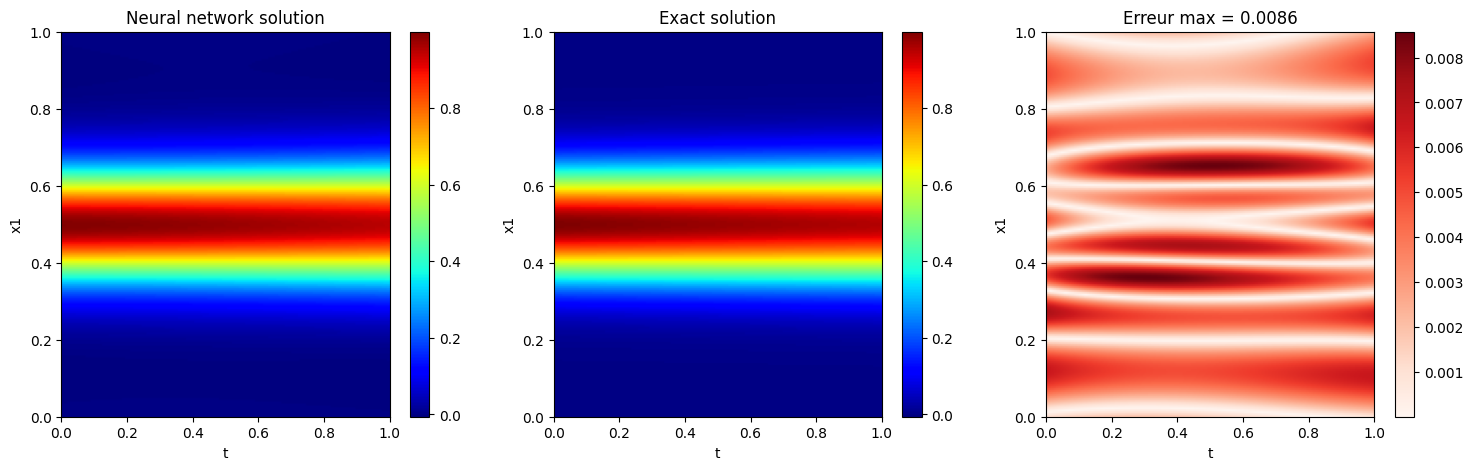

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

kwargs = dict(cmap='jet', vmin=vmin, vmax=vmax,
              aspect='auto', origin='lower',
              extent=[t_min, t_max, x_min, x_max])

im0 = axes[0].imshow(U_pinn.T, **kwargs)
axes[0].set_title('Neural network solution')
axes[0].set_xlabel('t'); axes[0].set_ylabel('x1')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(U_exact.T, **kwargs)
axes[1].set_title('Exact solution')
axes[1].set_xlabel('t'); axes[1].set_ylabel('x1')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(np.abs(U_pinn.T - U_exact.T),
                     cmap='Reds', aspect='auto', origin='lower',
                     extent=[t_min, t_max, x_min, x_max])
axes[2].set_title(f'Erreur max = {np.abs(U_pinn - U_exact).max():.4f}')
axes[2].set_xlabel('t'); axes[2].set_ylabel('x1')
plt.colorbar(im2, ax=axes[2])

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/solution_comparison_forward.png")
plt.show()


## Conclusion & Limits of `pinnDE`

- **Usability:** It is very straightforward to initialize, configure, and train simple PINN models using the `pinnDE` library.
- **Lack of Flexibility:** However, `pinnDE` lacks flexibility for defining custom loss weights, advanced boundary condition formulations, or custom neural network architectures.
- **Dimensionality Limit:** The library is strictly limited to solving equations in at most **1+2D** dimensions (1 time + 2 space dimensions). This represents a major limitation for our final objective of solving the **2D Radiative Transfer Equation (RTE/RFE)**, which involves an integro-differential equation over 2D space ($x, y$) and 2D direction ($\mu, \eta$), effectively requiring a higher-dimensional formulation. Therefore, we must build our PINN models from scratch using pure PyTorch.
